# DefectVision — 05 Threshold Calibration & Error Analysis

Notebook 04 established the first valid segmentation baseline.

This notebook does NOT retrain the model. It:
- selects a segmentation threshold using validation data only
- freezes that threshold
- evaluates the held-out test set
- compares the calibrated result with threshold 0.50
- analyzes performance by defect size
- identifies representative failure cases

The test set is never used to choose the threshold.


## 1. Imports and paths


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

PROJECT_ROOT = Path.cwd().resolve().parent
CHECKPOINT_DIR = PROJECT_ROOT / "models" / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "error_analysis"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cpu")
print("Device:", DEVICE)


Device: cpu


## 2. Recreate and load the baseline model


In [2]:
class DSConv(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, 3, stride, 1,
                      groups=in_channels, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class EfficientSegNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DSConv(3, 16, 2)
        self.enc2 = DSConv(16, 32, 2)
        self.enc3 = DSConv(32, 64, 2)
        self.enc4 = DSConv(64, 96, 2)
        self.bottleneck = DSConv(96, 128)
        self.dec4 = DSConv(128 + 64, 64)
        self.dec3 = DSConv(64 + 32, 32)
        self.dec2 = DSConv(32 + 16, 16)
        self.dec1 = DSConv(16 + 3, 8)
        self.out = nn.Conv2d(8, 1, 1)

    def up(self, x):
        return nn.functional.interpolate(
            x, scale_factor=2, mode="bilinear", align_corners=False
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b = self.bottleneck(e4)
        d4 = self.dec4(torch.cat([self.up(b), e3], 1))
        d3 = self.dec3(torch.cat([self.up(d4), e2], 1))
        d2 = self.dec2(torch.cat([self.up(d3), e1], 1))
        d1 = self.dec1(torch.cat([self.up(d2), x], 1))
        return self.out(d1)

model = EfficientSegNet().to(DEVICE)
checkpoint_path = CHECKPOINT_DIR / "efficient_baseline_best.pth"
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded:", checkpoint_path)
print("Best validation Dice:", checkpoint.get("val_dice"))
print("Best validation IoU:", checkpoint.get("val_iou"))


Loaded: C:\Documents\DefectVision\models\checkpoints\efficient_baseline_best.pth
Best validation Dice: 0.23084709304757284
Best validation IoU: 0.16114866987056897


## 3. Confirm the existing validation and test loaders


In [4]:
# Cell 3 — Recreate validation and test DataLoaders
# No training is performed here.

from PIL import Image
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random

DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "MVTecAD-SEG"
IMG_ROOT = DATA_ROOT / "imgs"
ANN_ROOT = DATA_ROOT / "annotations"

IMAGE_SIZE = 256
BATCH_SIZE = 4


class DefectDataset(Dataset):

    def __init__(self, split):
        self.split = split

        self.img_dir = IMG_ROOT / split
        self.mask_dir = ANN_ROOT / split

        self.image_paths = sorted(
            self.img_dir.glob("*.png")
        )

        if not self.image_paths:
            raise RuntimeError(
                f"No images found in {self.img_dir}"
            )

        missing = [
            p.name
            for p in self.image_paths
            if not (self.mask_dir / p.name).exists()
        ]

        if missing:
            raise RuntimeError(
                f"Missing masks in {split}: {missing[:5]}"
            )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        image_path = self.image_paths[idx]
        mask_path = self.mask_dir / image_path.name

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if image.size != (IMAGE_SIZE, IMAGE_SIZE):
            image = image.resize(
                (IMAGE_SIZE, IMAGE_SIZE),
                Image.Resampling.BILINEAR
            )

        if mask.size != (IMAGE_SIZE, IMAGE_SIZE):
            mask = mask.resize(
                (IMAGE_SIZE, IMAGE_SIZE),
                Image.Resampling.NEAREST
            )

        # Image → tensor
        image_np = np.asarray(
            image,
            dtype=np.float32
        ) / 255.0

        image_tensor = torch.from_numpy(
            image_np
        ).permute(2, 0, 1).contiguous()

        # Same normalization used in Notebook 04
        mean = torch.tensor(
            [0.485, 0.456, 0.406]
        ).view(3, 1, 1)

        std = torch.tensor(
            [0.229, 0.224, 0.225]
        ).view(3, 1, 1)

        image_tensor = (
            image_tensor - mean
        ) / std

        # Mask → binary tensor
        mask_np = np.asarray(
            mask,
            dtype=np.uint8
        )

        mask_tensor = torch.from_numpy(
            (mask_np > 0).astype(np.float32)
        ).unsqueeze(0)

        return (
            image_tensor,
            mask_tensor,
            image_path.stem
        )


# IMPORTANT:
# Only validation and test are loaded.
# No training data is needed for Notebook 05.

val_dataset = DefectDataset("val")
test_dataset = DefectDataset("test")

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Test batches:",
    len(test_loader)
)


Validation images: 125
Test images: 253
Validation batches: 32
Test batches: 64


## 4. Collect probabilities


In [5]:
@torch.no_grad()
def collect_outputs(model, loader):
    probs_all, masks_all, ids_all = [], [], []
    for images, masks, ids in loader:
        probs_all.append(torch.sigmoid(model(images.to(DEVICE))).cpu())
        masks_all.append(masks.cpu())
        ids_all.extend(list(ids))
    return torch.cat(probs_all), torch.cat(masks_all), ids_all

val_probs, val_masks, val_ids = collect_outputs(model, val_loader)
test_probs, test_masks, test_ids = collect_outputs(model, test_loader)

print("Validation:", tuple(val_probs.shape))
print("Test:", tuple(test_probs.shape))


Validation: (125, 1, 256, 256)
Test: (253, 1, 256, 256)


## 5. Threshold-independent metric function


In [6]:
def segmentation_scores(probs, masks, threshold=0.5, eps=1e-7):
    preds = (probs >= threshold).float()
    p = preds.flatten(1)
    t = masks.flatten(1)

    inter = (p * t).sum(1)
    pa, ta = p.sum(1), t.sum(1)
    union = pa + ta - inter

    dice = (2 * inter + eps) / (pa + ta + eps)
    iou = (inter + eps) / (union + eps)

    tp = inter
    fp = ((p == 1) & (t == 0)).sum(1).float()
    fn = ((p == 0) & (t == 1)).sum(1).float()

    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)

    return {
        "dice": dice.mean().item(),
        "iou": iou.mean().item(),
        "precision": precision.mean().item(),
        "recall": recall.mean().item()
    }


## 6. Validation-only threshold sweep


In [7]:
thresholds = np.arange(0.10, 0.91, 0.05)
rows = []

for t in thresholds:
    rows.append({
        "threshold": float(t),
        **segmentation_scores(val_probs, val_masks, float(t))
    })

threshold_df = pd.DataFrame(rows)
best = threshold_df.loc[threshold_df["dice"].idxmax()]
best_threshold = float(best["threshold"])

display(threshold_df)
print("Selected threshold:", best_threshold)
print("Best validation Dice:", best["dice"])
print("Best validation IoU:", best["iou"])


,threshold,dice,iou,precision,recall
0,0.10,0.138657,0.088686,0.089908,0.905157
1,0.15,0.174469,0.112040,0.118969,0.833278
2,0.20,0.194781,0.126466,0.153742,0.764237
3,0.25,0.201256,0.132026,0.171384,0.723678
4,0.30,0.206424,0.136623,0.196477,0.692124
5,0.35,0.211817,0.142002,0.212563,0.664071
6,0.40,0.225532,0.155017,0.253216,0.600237
7,0.45,0.231208,0.160817,0.317689,0.552401
8,0.50,0.230847,0.161149,0.327207,0.516127
9,0.55,0.230218,0.160926,0.337352,0.485804


Selected threshold: 0.45000000000000007
Best validation Dice: 0.2312079221010208
Best validation IoU: 0.16081717610359192


## 7. Threshold trade-off plot


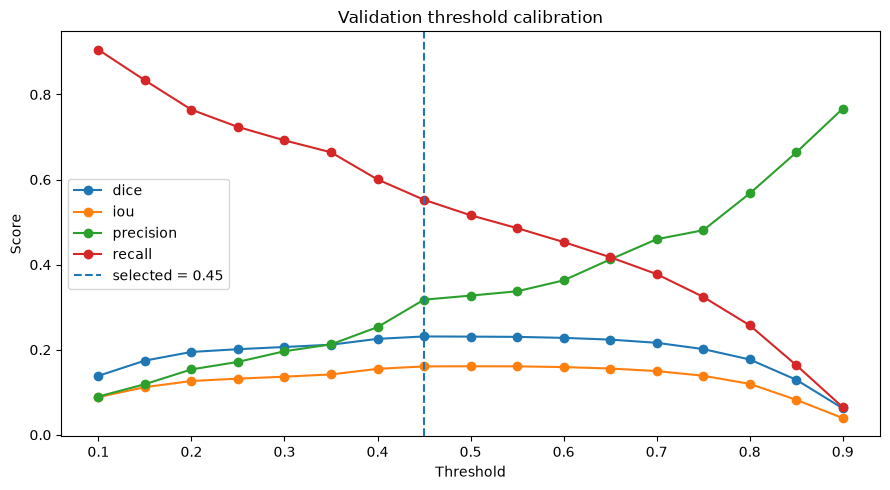

In [8]:
fig, ax = plt.subplots(figsize=(9,5))
for metric in ["dice", "iou", "precision", "recall"]:
    ax.plot(threshold_df["threshold"], threshold_df[metric],
            marker="o", label=metric)
ax.axvline(best_threshold, linestyle="--",
           label=f"selected = {best_threshold:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Validation threshold calibration")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "threshold_calibration.png",
            dpi=160, bbox_inches="tight")
plt.show()


## 8. Compare 0.50 with calibrated threshold on validation


In [9]:
val_comparison = pd.DataFrame([
    segmentation_scores(val_probs, val_masks, 0.50),
    segmentation_scores(val_probs, val_masks, best_threshold)
], index=["threshold_0.50", "calibrated"])

display(val_comparison)


,dice,iou,precision,recall
threshold_0.50,0.230847,0.161149,0.327207,0.516127
calibrated,0.231208,0.160817,0.317689,0.552401


## 9. Evaluate the frozen threshold on the held-out test set


In [10]:
test_comparison = pd.DataFrame([
    segmentation_scores(test_probs, test_masks, 0.50),
    segmentation_scores(test_probs, test_masks, best_threshold)
], index=["threshold_0.50", "calibrated"])

display(test_comparison)

pd.DataFrame([{
    "selected_threshold": best_threshold,
    "val_dice": best["dice"],
    "val_iou": best["iou"],
    "test_dice": test_comparison.loc["calibrated", "dice"],
    "test_iou": test_comparison.loc["calibrated", "iou"],
    "test_precision": test_comparison.loc["calibrated", "precision"],
    "test_recall": test_comparison.loc["calibrated", "recall"]
}]).to_csv(RESULTS_DIR / "calibrated_baseline_summary.csv", index=False)

threshold_df.to_csv(RESULTS_DIR / "validation_threshold_sweep.csv", index=False)


,dice,iou,precision,recall
threshold_0.50,0.206994,0.14344,0.313602,0.539982
calibrated,0.205625,0.14179,0.264746,0.568833


## 10. Defect-size analysis


In [11]:
SMALL = 0.0072784423828125
MEDIUM = 0.0278472900390625

def size_group(frac):
    if frac < SMALL:
        return "small"
    if frac < MEDIUM:
        return "medium"
    return "large"

preds = (test_probs >= best_threshold).float()
rows = []

for i, image_id in enumerate(test_ids):
    mask = test_masks[i, 0]
    pred = preds[i, 0]

    true_area = mask.sum().item()
    pred_area = pred.sum().item()
    inter = (mask * pred).sum().item()
    union = true_area + pred_area - inter

    rows.append({
        "image_id": image_id,
        "defect_fraction": true_area / mask.numel(),
        "size_group": size_group(true_area / mask.numel()),
        "dice": (2 * inter + 1e-7) / (true_area + pred_area + 1e-7),
        "iou": (inter + 1e-7) / (union + 1e-7),
        "true_pixels": true_area,
        "predicted_pixels": pred_area,
        "false_positive_pixels": max(pred_area - inter, 0),
        "false_negative_pixels": max(true_area - inter, 0)
    })

error_df = pd.DataFrame(rows)

size_summary = (
    error_df.groupby("size_group")
    .agg(
        images=("image_id", "count"),
        mean_defect_fraction=("defect_fraction", "mean"),
        mean_dice=("dice", "mean"),
        mean_iou=("iou", "mean")
    )
    .reindex(["small", "medium", "large"])
)

display(size_summary)
error_df.to_csv(RESULTS_DIR / "test_image_level_error_analysis.csv", index=False)
size_summary.to_csv(RESULTS_DIR / "test_size_group_performance.csv")


,images,mean_defect_fraction,mean_dice,mean_iou
size_group,,,,
small,94,0.003912,0.040149,0.022303
medium,78,0.016454,0.160123,0.096151
large,81,0.121698,0.441476,0.324403


## 11. Visualize size-wise performance


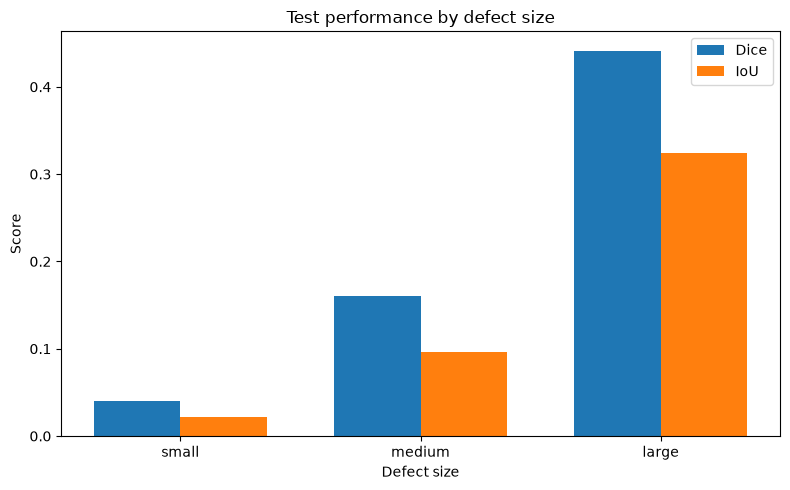

In [12]:
fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(len(size_summary))
ax.bar(x - 0.18, size_summary["mean_dice"], 0.36, label="Dice")
ax.bar(x + 0.18, size_summary["mean_iou"], 0.36, label="IoU")
ax.set_xticks(x)
ax.set_xticklabels(size_summary.index)
ax.set_xlabel("Defect size")
ax.set_ylabel("Score")
ax.set_title("Test performance by defect size")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "performance_by_defect_size.png",
            dpi=160, bbox_inches="tight")
plt.show()


## 12. Identify representative failure cases


In [13]:
print("Worst Dice:")
display(error_df.nsmallest(10, "dice")[
    ["image_id","size_group","defect_fraction","dice","iou"]
])

print("Largest false-positive burdens:")
display(error_df.nlargest(10, "false_positive_pixels")[
    ["image_id","size_group","true_pixels",
     "predicted_pixels","false_positive_pixels"]
])

print("Largest false-negative burdens:")
display(error_df.nlargest(10, "false_negative_pixels")[
    ["image_id","size_group","true_pixels",
     "predicted_pixels","false_negative_pixels"]
])


Worst Dice:


,image_id,size_group,defect_fraction,dice,iou
191,757,medium,0.014801,6.692097e-12,6.692097e-12
170,665,small,0.000641,9.661836e-12,9.661836e-12
124,377,small,0.005585,1.129305e-11,1.129305e-11
42,1204,medium,0.025879,1.181335e-11,1.181335e-11
43,1205,medium,0.015671,1.620483e-11,1.620483e-11
201,806,small,0.003632,1.744287e-11,1.744287e-11
81,202,small,0.001587,1.957713e-11,1.957713e-11
66,162,small,0.004898,1.971220e-11,1.971220e-11
39,1194,medium,0.007980,2.206045e-11,2.206045e-11
70,169,small,0.000992,2.407898e-11,2.407898e-11


Largest false-positive burdens:


,image_id,size_group,true_pixels,predicted_pixels,false_positive_pixels
12,1055,medium,998.0,51861.0,50863.0
11,1051,medium,681.0,44306.0,43625.0
15,1061,small,415.0,41714.0,41299.0
10,1044,medium,1041.0,38524.0,37504.0
13,1058,medium,1154.0,38315.0,37161.0
140,489,medium,1109.0,36490.0,35658.0
139,487,small,455.0,35849.0,35501.0
141,496,medium,1114.0,36249.0,35304.0
153,565,large,2145.0,37167.0,35022.0
142,501,medium,1313.0,35979.0,34727.0


Largest false-negative burdens:


,image_id,size_group,true_pixels,predicted_pixels,false_negative_pixels
195,776,large,26771.0,12637.0,14836.0
196,780,large,26737.0,17873.0,10041.0
157,58,large,9892.0,8633.0,9610.0
251,993,large,12865.0,6772.0,6965.0
250,991,large,15406.0,10377.0,6707.0
158,6,large,10013.0,11204.0,5371.0
99,298,large,4575.0,309.0,4537.0
247,980,large,8627.0,6361.0,4331.0
18,1087,large,9622.0,5986.0,3938.0
130,43,large,4700.0,13018.0,3454.0


## 13. Visualize the worst-Dice examples


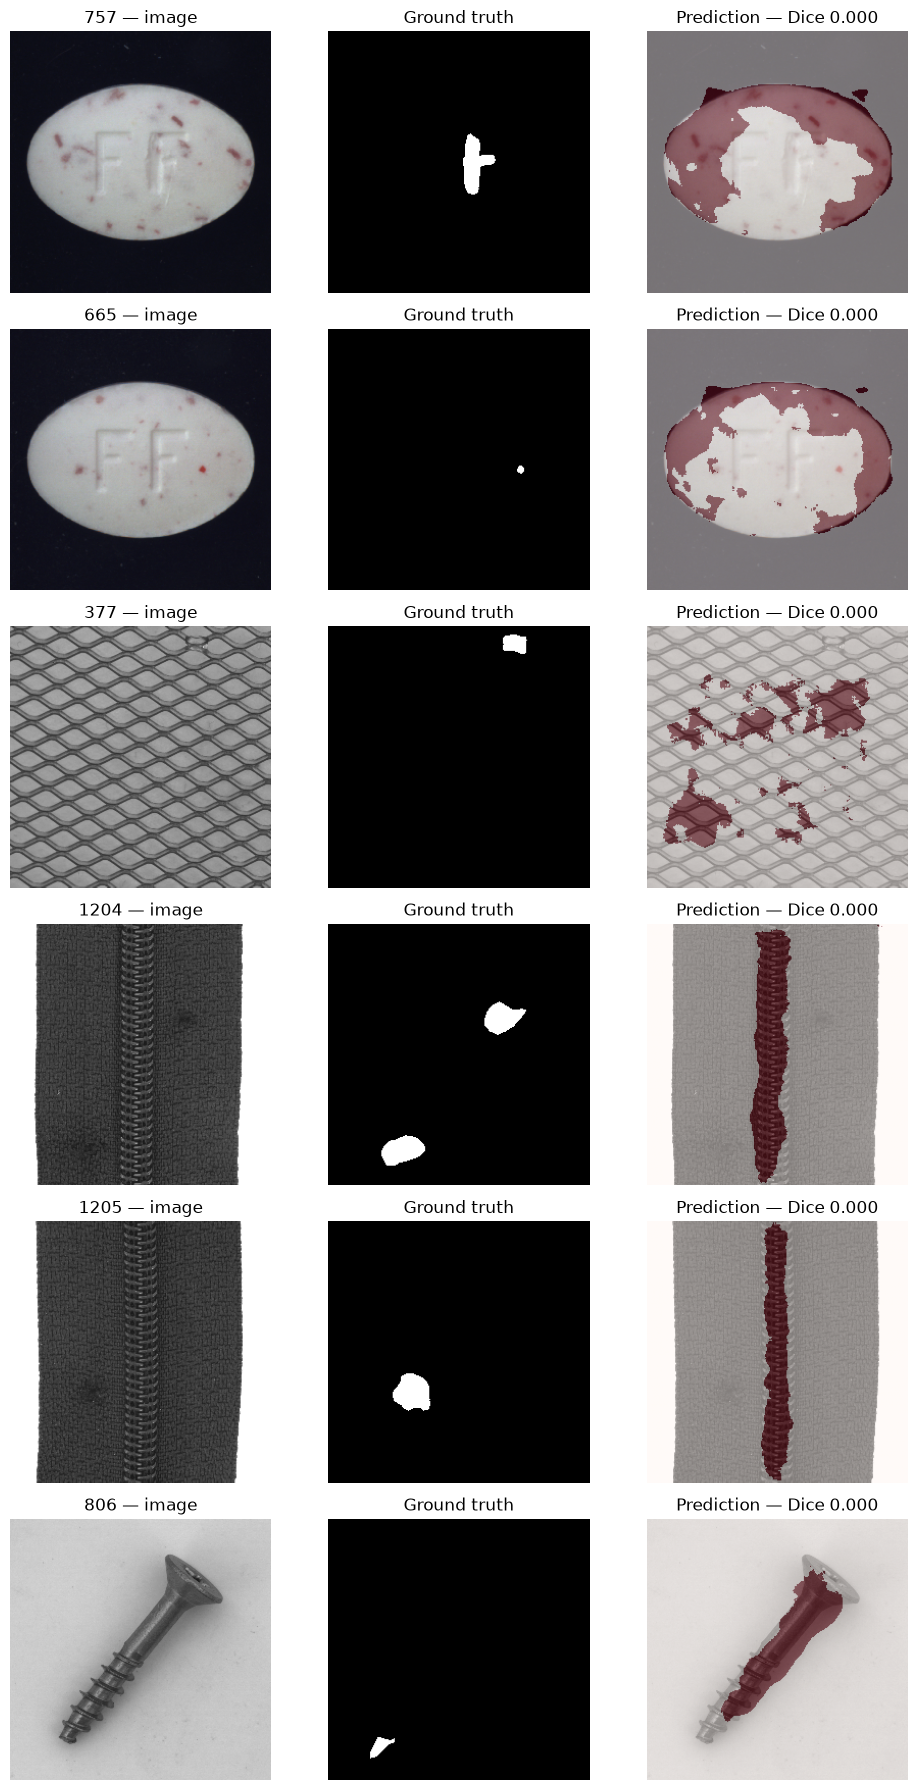

In [14]:
@torch.no_grad()
def predict_dataset_item(index):
    image, mask, image_id = test_loader.dataset[index]
    prob = torch.sigmoid(model(image.unsqueeze(0)))[0,0]
    return image, mask[0], prob, image_id

mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

worst = error_df.nsmallest(6, "dice")

fig, axes = plt.subplots(len(worst), 3,
                         figsize=(10, 3*len(worst)))
if len(worst) == 1:
    axes = np.expand_dims(axes, 0)

for r, (_, row) in enumerate(worst.iterrows()):
    index = next(
        i for i,p in enumerate(test_loader.dataset.image_paths)
        if p.stem == row["image_id"]
    )

    image, mask, prob, image_id = predict_dataset_item(index)

    image = (image * std + mean).clamp(0,1)
    image = image.permute(1,2,0).numpy()

    gt = mask.numpy()
    pred = (prob.numpy() >= best_threshold).astype(float)

    axes[r,0].imshow(image)
    axes[r,0].set_title(f"{image_id} — image")
    axes[r,0].axis("off")

    axes[r,1].imshow(gt, cmap="gray")
    axes[r,1].set_title("Ground truth")
    axes[r,1].axis("off")

    axes[r,2].imshow(image)
    axes[r,2].imshow(pred, cmap="Reds", alpha=0.45)
    axes[r,2].set_title(f"Prediction — Dice {row['dice']:.3f}")
    axes[r,2].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "worst_dice_cases.png",
            dpi=160, bbox_inches="tight")
plt.show()


## 14. Interpretation

The important outputs are:

- selected validation threshold
- calibrated test Dice / IoU
- small vs medium vs large defect performance
- worst-Dice examples
- false-positive and false-negative cases

These results will determine what the stronger model must improve.

**Do not tune anything using the test set.**
